MODEL EVALUATION LAB - STUDENT VERSION

PART 1: CLASSIFICATION EVALUATION - BREAST CANCER DATASET

Dataset Shape: (569, 30)
Number of Features: 30
Number of Samples: 569

Class Distribution:
target
1    357
0    212
Name: count, dtype: int64

--------------------------------------------------------------------------------
Exercise 1.1: Train-Test Split
--------------------------------------------------------------------------------
Training set size: 455
Test set size: 114

--------------------------------------------------------------------------------
Exercise 1.2: Train and Evaluate Logistic Regression
--------------------------------------------------------------------------------
Training Accuracy: 0.9890
Test Accuracy: 0.9825
The model is well-fitted because training and test accuracies are similar.

--------------------------------------------------------------------------------
Exercise 1.3: Confusion Matrix Analysis
-------------------------------------------------------------

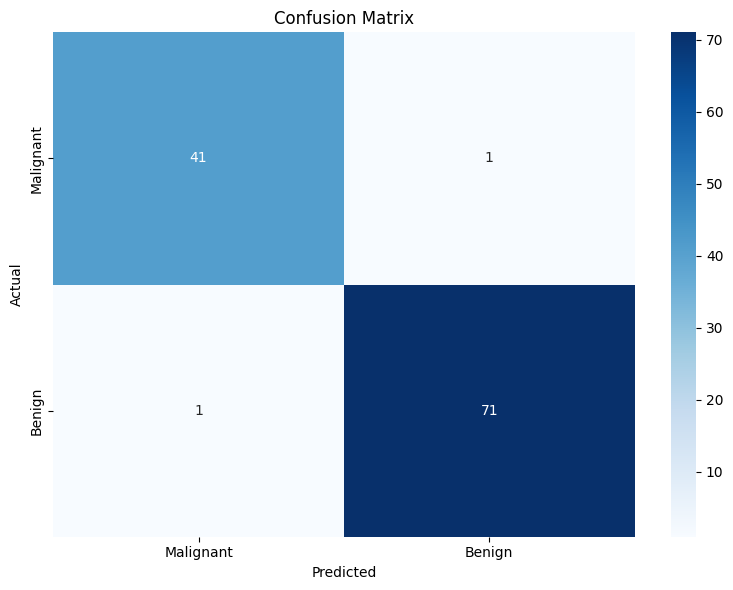


--------------------------------------------------------------------------------
Exercise 1.4: Precision, Recall, and F1 Score
--------------------------------------------------------------------------------
Precision: 0.9861
Recall: 0.9861
F1 Score: 0.9861

Of all predicted positive (Benign) cases, 98.61% are actually benign.
Out of all actual benign cases, 98.61% were correctly identified by the model.
The F1 score balances precision and recall, and here it is 98.61%.

Classification Report:
              precision    recall  f1-score   support

   Malignant       0.98      0.98      0.98        42
      Benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114


--------------------------------------------------------------------------------
Exercise 1.5: ROC Curve and AUC
-----------------------------------------------------------

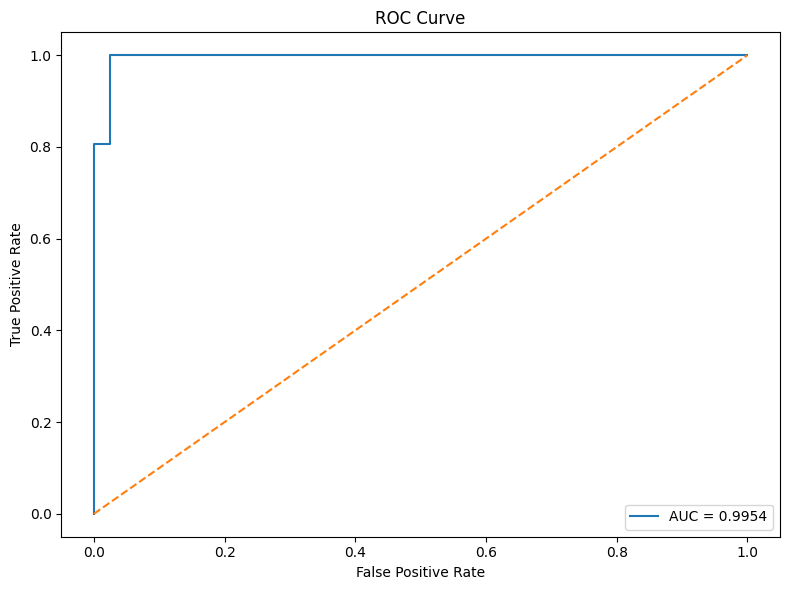


--------------------------------------------------------------------------------
Exercise 1.6: K-Fold Cross-Validation
--------------------------------------------------------------------------------
  Fold 1: 0.9737
  Fold 2: 0.9474
  Fold 3: 0.9649
  Fold 4: 0.9912
  Fold 5: 0.9912

Mean CV Accuracy: 0.9737
Standard Deviation: 0.0166
95% Confidence Interval: (0.9411, 1.0000)

Single Train-Test Accuracy: 0.9825
Cross-validation accuracy is very close to test accuracy, so the model is stable and generalizes well.

--------------------------------------------------------------------------------
Exercise 1.7: Compare Multiple Classifiers
--------------------------------------------------------------------------------

Model Comparison:
              Model  Accuracy  Precision   Recall  F1 Score      AUC
Logistic Regression  0.982456   0.986111 0.986111  0.986111 0.995370
      Decision Tree  0.921053   0.956522 0.916667  0.936170 0.916336
      Random Forest  0.956140   0.958904 0.97222

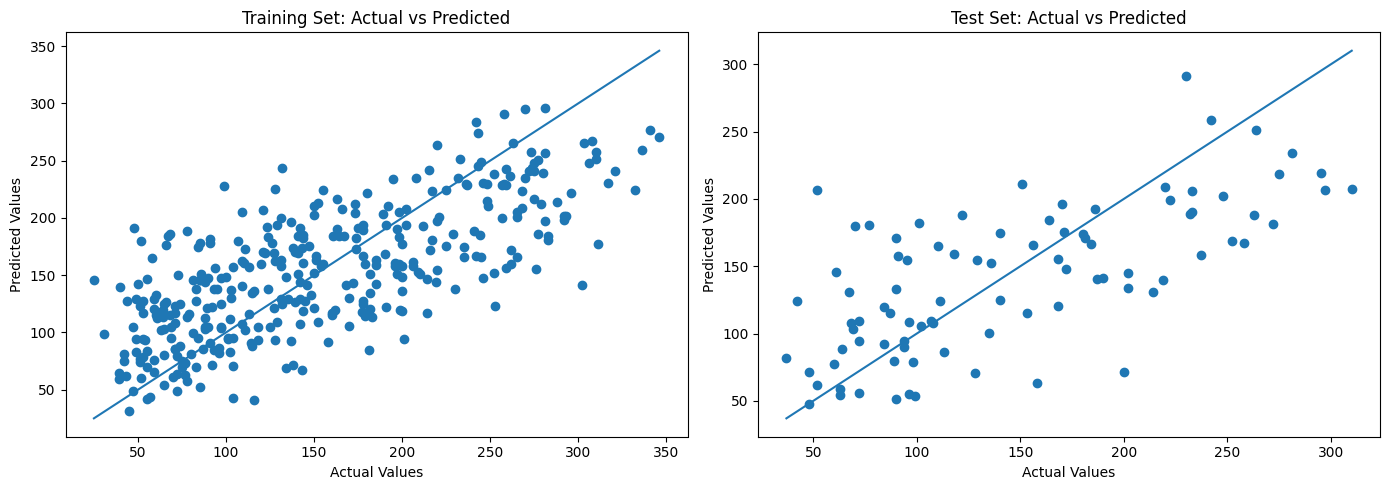


--------------------------------------------------------------------------------
Exercise 2.4: Residual Analysis
--------------------------------------------------------------------------------
Residual Mean: 3.9128
Residual Standard Deviation: 54.0154
Residual Min: -154.4934
Residual Max: 128.3333


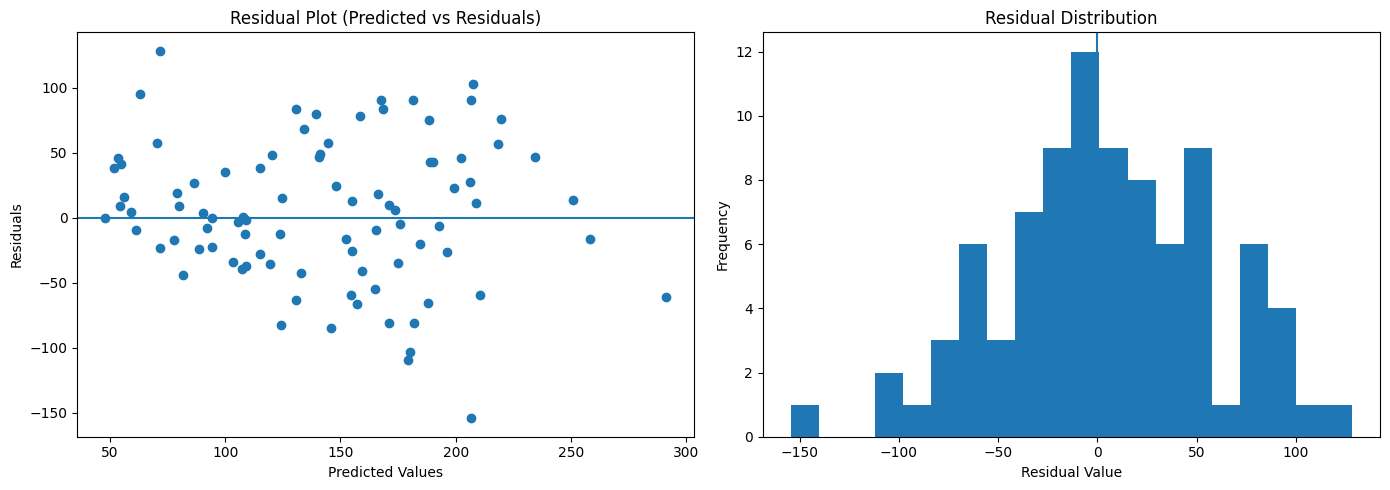


--------------------------------------------------------------------------------
Exercise 2.5: Compare Multiple Regression Models
--------------------------------------------------------------------------------

Regression Model Comparison:
             Model  Train R²  Test R²       MAE      RMSE  Overfit Gap
 Linear Regression  0.527919 0.452603 42.794095 53.853446     0.075317
 Ridge (alpha=1.0)  0.527632 0.454147 42.811999 53.777454     0.073485
Ridge (alpha=10.0)  0.524798 0.457211 42.856825 53.626288     0.067587
     Decision Tree  0.668606 0.334482 45.936955 59.380262     0.334124

Best Model based on Test R²: Ridge (alpha=10.0)
Test R²: 0.4572

--------------------------------------------------------------------------------
Exercise 2.6: Cross-Validation for Regression
--------------------------------------------------------------------------------
R² Scores for each fold:
  Fold 1: 0.4296
  Fold 2: 0.5226
  Fold 3: 0.4827
  Fold 4: 0.4265
  Fold 5: 0.5502

Mean R²: 0.4823
St

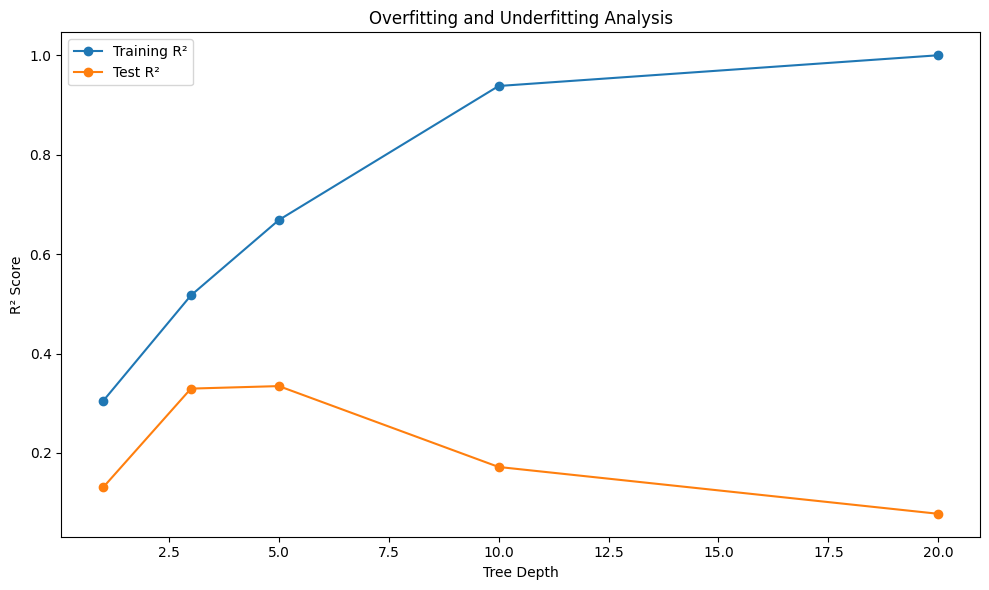

'\nBefore submitting, ensure you have:\nCompleted all TODO items\nGenerated all required visualizations\nAnswered all assessment questions\nTested your code and verified it runs without errors\nInterpreted your results with comments\nCompared model performances\nAnalyzed overfitting/underfitting\n\nExpected output files:\n- confusion_matrix_student.png\n- roc_curve_student.png\n- regression_predictions_student.png\n- residual_analysis_student.png\n- overfitting_analysis_student.png\n'

In [2]:
# Model Evaluation Lab
# Complete the exercises by filling in the code where indicated with TODO

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, KFold, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, LinearRegression, Ridge
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, roc_auc_score,
    mean_absolute_error, mean_squared_error, r2_score
)
from sklearn.datasets import load_breast_cancer, load_diabetes
import warnings
warnings.filterwarnings('ignore')

print("=" * 80)
print("MODEL EVALUATION LAB - STUDENT VERSION")
print("=" * 80)

# ============================================================================
# PART 1: CLASSIFICATION EVALUATION
# ============================================================================

print("\n" + "=" * 80)
print("PART 1: CLASSIFICATION EVALUATION - BREAST CANCER DATASET")
print("=" * 80)

# Load the breast cancer dataset
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name='target')

print(f"\nDataset Shape: {X.shape}")
print(f"Number of Features: {X.shape[1]}")
print(f"Number of Samples: {X.shape[0]}")
print(f"\nClass Distribution:")
print(y.value_counts())

# ============================================================================
# Exercise 1.1: Train-Test Split
# Task: Split the data into training (80%) and test (20%) sets
# Use stratified sampling to maintain class distribution
# Set random_state=42 for reproducibility
# ============================================================================

print("\n" + "-" * 80)
print("Exercise 1.1: Train-Test Split")
print("-" * 80)

# TODO: Split the data using train_test_split
# Hint: Use test_size=0.2, random_state=42, and stratify=y

# Splits the data (80-20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# TODO: Print the sizes of training and test sets
# print(f"Training set size: {X_train.shape[0]}")
# print(f"Test set size: {X_test.shape[0]}")

print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")


# TODO: Standardize the features using StandardScaler
# Remember: fit_transform on training, transform on test

# Standardize features
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)   # Fit only on training
X_test_scaled = scaler.transform(X_test)         # Transforms test using same scaler


# ============================================================================
# Exercise 1.2: Train and Evaluate Logistic Regression
# Task: Train a logistic regression model and calculate accuracy
# ============================================================================

print("\n" + "-" * 80)
print("Exercise 1.2: Train and Evaluate Logistic Regression")
print("-" * 80)

# TODO: Create and train a LogisticRegression model
# Hint: Use max_iter=10000, random_state=42

# Create Logistic Regression model
log_reg = LogisticRegression(max_iter=10000, random_state=42)

# TODO: Fit the model on scaled training data

# Train the model using scaled training data
log_reg.fit(X_train_scaled, y_train)


# TODO: Make predictions on both training and test sets

# TODO: Predict on training set
y_pred_train = log_reg.predict(X_train_scaled)

# TODO: Predict on test set
y_pred_test = log_reg.predict(X_test_scaled)

# TODO: Calculate accuracy for both sets
# TODO: Calculate training accuracy
train_accuracy = accuracy_score(y_train, y_pred_train)

# TODO: Calculate test accuracy
test_accuracy = accuracy_score(y_test, y_pred_test)

# TODO: Print the accuracies and interpret the results
print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

# Is the model overfitting, underfitting, or well-fitted?
if train_accuracy - test_accuracy > 0.05:
    print("The model is slightly overfitting because training accuracy is higher than test accuracy.")
elif train_accuracy < 0.85 and test_accuracy < 0.85:
    print("The model is underfitting since both accuracies are relatively low.")
else:
    print("The model is well-fitted because training and test accuracies are similar.")
# ============================================================================
# Exercise 1.3: Confusion Matrix Analysis
# Task: Create a confusion matrix and extract TP, TN, FP, FN
# ============================================================================

print("\n" + "-" * 80)
print("Exercise 1.3: Confusion Matrix Analysis")
print("-" * 80)

# TODO: Create confusion matrix for test predictions
cm = confusion_matrix(y_test, y_pred_test)

# TODO: Print the confusion matrix
print("\nConfusion Matrix:")
print(cm)

# TODO: Extract TP, TN, FP, FN from confusion matrix
# Hint: Use cm.ravel() or index directly
tn, fp, fn, tp = cm.ravel()

# TODO: Calculate metrics manually using the formulas:
# Accuracy = (TP + TN) / (TP + TN + FP + FN)
# Precision = TP / (TP + FP)
# Recall = TP / (TP + FN)
# F1 Score = 2 * (Precision * Recall) / (Precision + Recall)

manual_accuracy = (tp + tn) / (tp + tn + fp + fn)
manual_precision = tp / (tp + fp)
manual_recall = tp / (tp + fn)
manual_f1 = 2 * (manual_precision * manual_recall) / (manual_precision + manual_recall)

# TODO: Print the manually calculated metrics
print(f"\nManual Accuracy: {manual_accuracy:.4f}")
print(f"Manual Precision: {manual_precision:.4f}")
print(f"Manual Recall: {manual_recall:.4f}")
print(f"Manual F1 Score: {manual_f1:.4f}")

# TODO: Visualize the confusion matrix using seaborn heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Malignant', 'Benign'],
            yticklabels=['Malignant', 'Benign'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.savefig('confusion_matrix_student.png')
plt.show()
plt.close()

# ============================================================================
# Exercise 1.4: Precision, Recall, and F1 Score
# Task: Calculate metrics using sklearn functions and interpret them
# ============================================================================

print("\n" + "-" * 80)
print("Exercise 1.4: Precision, Recall, and F1 Score")
print("-" * 80)

# TODO: Calculate metrics using sklearn functions
precision = precision_score(y_test, y_pred_test)
recall = recall_score(y_test, y_pred_test)
f1 = f1_score(y_test, y_pred_test)

# TODO: Print the metrics with interpretations
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

print(f"\nOf all predicted positive (Benign) cases, {precision*100:.2f}% are actually benign.")
print(f"Out of all actual benign cases, {recall*100:.2f}% were correctly identified by the model.")
print(f"The F1 score balances precision and recall, and here it is {f1*100:.2f}%.")

# TODO: Print the full classification report
# Hint: Use classification_report with target_names=['Malignant', 'Benign']
print("\nClassification Report:")
print(classification_report(y_test, y_pred_test,
                            target_names=['Malignant', 'Benign']))

# ============================================================================
# Exercise 1.5: ROC Curve and AUC
# Task: Generate ROC curve and calculate AUC score
# ============================================================================

print("\n" + "-" * 80)
print("Exercise 1.5: ROC Curve and AUC")
print("-" * 80)

# TODO: Get predicted probabilities for the positive class
y_pred_proba = log_reg.predict_proba(X_test_scaled)[:, 1]  # probability of positive class (Benign)

# TODO: Calculate ROC curve coordinates
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

# TODO: Calculate AUC score
auc_score = roc_auc_score(y_test, y_pred_proba)

# TODO: Print AUC score and interpret it
# AUC >= 0.9: Excellent, >= 0.8: Good, >= 0.7: Acceptable, < 0.7: Poor
print(f"AUC Score: {auc_score:.4f}")

if auc_score >= 0.9:
    print("The model performance is Excellent based on AUC.")
elif auc_score >= 0.8:
    print("The model performance is Good based on AUC.")
elif auc_score >= 0.7:
    print("The model performance is Acceptable based on AUC.")
else:
    print("The model performance is Poor based on AUC.")

# TODO: Plot ROC curve
plt.figure(figsize=(8, 6))

# Plot ROC curve
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.4f}")

# Plot diagonal line for random classifier
plt.plot([0, 1], [0, 1], linestyle='--')

# Add labels, title, legend
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.tight_layout()
plt.savefig('roc_curve_student.png')
plt.show()
plt.close()
# ============================================================================
# Exercise 1.6: K-Fold Cross-Validation
# Task: Perform 5-fold stratified cross-validation
# ============================================================================

print("\n" + "-" * 80)
print("Exercise 1.6: K-Fold Cross-Validation")
print("-" * 80)

# TODO: Create StratifiedKFold with 5 splits
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# TODO: Scale the entire dataset
scaler_full = StandardScaler()
X_scaled_full = scaler_full.fit_transform(X)

# TODO: Perform cross-validation
cv_scores = cross_val_score(log_reg, X_scaled_full, y, cv=kfold)

# TODO: Print individual fold scores
for i, score in enumerate(cv_scores, 1):
    print(f"  Fold {i}: {score:.4f}")

# TODO: Calculate and print mean and standard deviation
# Also calculate 95% confidence interval
mean_cv = cv_scores.mean()
std_cv = cv_scores.std()

confidence_interval_low = mean_cv - 1.96 * std_cv
confidence_interval_high = mean_cv + 1.96 * std_cv
confidence_interval_high = min(1.0, confidence_interval_high)

print(f"\nMean CV Accuracy: {mean_cv:.4f}")
print(f"Standard Deviation: {std_cv:.4f}")
print(f"95% Confidence Interval: ({confidence_interval_low:.4f}, {confidence_interval_high:.4f})")

# TODO: Compare with single train-test split accuracy
print(f"\nSingle Train-Test Accuracy: {test_accuracy:.4f}")

if abs(mean_cv - test_accuracy) < 0.02:
    print("Cross-validation accuracy is very close to test accuracy, so the model is stable and generalizes well.")
else:
    print("There is some difference between CV and test accuracy, further evaluation may be needed.")

# ============================================================================
# Exercise 1.7: Compare Multiple Classifiers
# Task: Train and compare Logistic Regression, Decision Tree, and Random Forest
# ============================================================================

print("\n" + "-" * 80)
print("Exercise 1.7: Compare Multiple Classifiers")
print("-" * 80)

# TODO: Define a dictionary of models
models = {
    'Logistic Regression': LogisticRegression(max_iter=10000, random_state=42),  # TODO: Create model
    'Decision Tree': DecisionTreeClassifier(max_depth=5, random_state=42),         # TODO: Create model (max_depth=5)
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42)          # TODO: Create model (n_estimators=100)
}

results = []

# TODO: Loop through each model
for name, model in models.items():
    # TODO: Train the model
    model.fit(X_train_scaled, y_train)
    
    # TODO: Make predictions
    y_pred = model.predict(X_test_scaled)         # TODO: Predict classes
    y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]   # TODO: Predict probabilities
    
    # TODO: Calculate all metrics
    acc = accuracy_score(y_test, y_pred)    # TODO: Calculate accuracy
    prec = precision_score(y_test, y_pred)   # TODO: Calculate precision
    rec = recall_score(y_test, y_pred)    # TODO: Calculate recall
    f1_val = f1_score(y_test, y_pred)  # TODO: Calculate f1 score
    auc = roc_auc_score(y_test, y_pred_proba)    # TODO: Calculate AUC
    
    # TODO: Append results to list
    results.append({
        'Model': name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1 Score': f1_val,
        'AUC': auc
    })

# TODO: Create DataFrame and print comparison
results_df = pd.DataFrame(results)
print("\nModel Comparison:")
print(results_df.to_string(index=False))

# TODO: Identify and print the best model by F1 Score
best_model = results_df.loc[results_df['F1 Score'].idxmax()]
print(f"\nBest Model based on F1 Score: {best_model['Model']}")
print(f"F1 Score: {best_model['F1 Score']:.4f}")

# ============================================================================
# PART 2: REGRESSION EVALUATION
# ============================================================================

print("\n" + "=" * 80)
print("PART 2: REGRESSION EVALUATION - DIABETES DATASET")
print("=" * 80)

# Load diabetes dataset
diabetes = load_diabetes()
X_reg = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)
y_reg = pd.Series(diabetes.target, name='target')

print(f"\nDataset Shape: {X_reg.shape}")
print(f"\nTarget Statistics:")
print(y_reg.describe())

# ============================================================================
# Exercise 2.1: Train-Test Split for Regression
# Task: Split regression data into training and test sets
# ============================================================================

print("\n" + "-" * 80)
print("Exercise 2.1: Train-Test Split for Regression")
print("-" * 80)

# TODO: Split the regression data (80-20 split)
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg,
    test_size=0.2,
    random_state=42
)

# TODO: Print set sizes
print(f"Training set size: {X_train_reg.shape[0]}")
print(f"Test set size: {X_test_reg.shape[0]}")

# TODO: Standardize features
scaler_reg = StandardScaler()
X_train_reg_scaled = scaler_reg.fit_transform(X_train_reg)  # TODO: fit and transform
X_test_reg_scaled = scaler_reg.transform(X_test_reg)   # TODO: transform only

# ============================================================================
# Exercise 2.2: Train Linear Regression and Calculate Metrics
# Task: Train linear regression and calculate MAE, MSE, RMSE, R²
# ============================================================================

print("\n" + "-" * 80)
print("Exercise 2.2: Train Linear Regression and Calculate Metrics")
print("-" * 80)

# TODO: Create and train LinearRegression model
lin_reg = LinearRegression()  # TODO: Create model

# TODO: Fit on training data
lin_reg.fit(X_train_reg_scaled, y_train_reg)

# TODO: Make predictions on both sets
y_pred_train_reg = lin_reg.predict(X_train_reg_scaled)  # TODO: Predict on training
y_pred_test_reg = lin_reg.predict(X_test_reg_scaled)   # TODO: Predict on test

# TODO: Calculate MAE for both sets
train_mae = mean_absolute_error(y_train_reg, y_pred_train_reg)  # TODO: Calculate training MAE
test_mae = mean_absolute_error(y_test_reg, y_pred_test_reg)   # TODO: Calculate test MAE

# TODO: Calculate MSE for both sets
train_mse = mean_squared_error(y_train_reg, y_pred_train_reg)  # TODO: Calculate training MSE
test_mse = mean_squared_error(y_test_reg, y_pred_test_reg)   # TODO: Calculate test MSE

# TODO: Calculate RMSE (square root of MSE)
train_rmse = np.sqrt(train_mse)  # TODO: Calculate
test_rmse = np.sqrt(test_mse)   # TODO: Calculate

# TODO: Calculate R² score for both sets
train_r2 = r2_score(y_train_reg, y_pred_train_reg)  # TODO: Calculate training R²
test_r2 = r2_score(y_test_reg, y_pred_test_reg)   # TODO: Calculate test R²

# TODO: Print all metrics with interpretations
# For example: "Average prediction error is X units"
# "Model explains X% of variance"

print(f"Training MAE: {train_mae:.4f}")
print(f"Test MAE: {test_mae:.4f}")

print(f"\nTraining RMSE: {train_rmse:.4f}")
print(f"Test RMSE: {test_rmse:.4f}")

print(f"\nTraining R²: {train_r2:.4f}")
print(f"Test R²: {test_r2:.4f}")

print(f"\nOn average, the model's prediction error on the test set is about {test_mae:.2f} units.")
print(f"The model explains approximately {test_r2*100:.2f}% of the variance in the target variable on the test data.")

# ============================================================================
# Exercise 2.3: Visualize Predictions vs Actual
# Task: Create scatter plots comparing predictions to actual values
# ============================================================================

print("\n" + "-" * 80)
print("Exercise 2.3: Visualize Predictions vs Actual")
print("-" * 80)

# TODO: Create figure with 2 subplots (1 row, 2 columns)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# TODO: Plot training set (left subplot)
# Scatter plot of actual vs predicted
axes[0].scatter(y_train_reg, y_pred_train_reg)

# Add perfect prediction line (y=x)
axes[0].plot([y_train_reg.min(), y_train_reg.max()],
             [y_train_reg.min(), y_train_reg.max()])

# Add labels, title, legend
axes[0].set_xlabel("Actual Values")
axes[0].set_ylabel("Predicted Values")
axes[0].set_title("Training Set: Actual vs Predicted")

# TODO: Plot test set (right subplot)
# Same as training set plot
axes[1].scatter(y_test_reg, y_pred_test_reg)

axes[1].plot([y_test_reg.min(), y_test_reg.max()],
             [y_test_reg.min(), y_test_reg.max()])

axes[1].set_xlabel("Actual Values")
axes[1].set_ylabel("Predicted Values")
axes[1].set_title("Test Set: Actual vs Predicted")

# Show the figure
plt.tight_layout()
plt.savefig('regression_predictions_student.png')
plt.show()
plt.close()
# ============================================================================
# Exercise 2.4: Residual Analysis
# Task: Calculate and visualize residuals
# ============================================================================

print("\n" + "-" * 80)
print("Exercise 2.4: Residual Analysis")
print("-" * 80)

# TODO: Calculate residuals (actual - predicted)
residuals = y_test_reg - y_pred_test_reg  # TODO: Calculate for test set

# TODO: Print residual statistics
# Mean (should be close to 0)
# Standard deviation
# Min and max values
print(f"Residual Mean: {residuals.mean():.4f}")
print(f"Residual Standard Deviation: {residuals.std():.4f}")
print(f"Residual Min: {residuals.min():.4f}")
print(f"Residual Max: {residuals.max():.4f}")

# TODO: Create figure with 2 subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# TODO: Left subplot - Residual plot
# Scatter plot of predicted values vs residuals
axes[0].scatter(y_pred_test_reg, residuals)

# Add horizontal line at y=0
axes[0].axhline(y=0)

axes[0].set_xlabel("Predicted Values")
axes[0].set_ylabel("Residuals")
axes[0].set_title("Residual Plot (Predicted vs Residuals)")

# TODO: Right subplot - Residual distribution
# Histogram of residuals
axes[1].hist(residuals, bins=20)

# Add vertical line at x=0
axes[1].axvline(x=0)

axes[1].set_xlabel("Residual Value")
axes[1].set_ylabel("Frequency")
axes[1].set_title("Residual Distribution")

# TODO: Show the figure
plt.tight_layout()
plt.savefig('residual_analysis_student.png')
plt.show()
plt.close()
# ============================================================================
# Exercise 2.5: Compare Multiple Regression Models
# Task: Compare Linear Regression, Ridge (two alpha values), and Decision Tree
# ============================================================================

print("\n" + "-" * 80)
print("Exercise 2.5: Compare Multiple Regression Models")
print("-" * 80)

# TODO: Define dictionary of regression models
reg_models = {
    'Linear Regression': LinearRegression(),                 # TODO: Create model
    'Ridge (alpha=1.0)': Ridge(alpha=1.0, random_state=42),        # TODO: Create Ridge with alpha=1.0
    'Ridge (alpha=10.0)': Ridge(alpha=10.0, random_state=42),       # TODO: Create Ridge with alpha=10.0
    'Decision Tree': DecisionTreeRegressor(max_depth=5, random_state=42)     # TODO: Create DecisionTreeRegressor (max_depth=5)
}

reg_results = []

# TODO: Loop through each model
for name, model in reg_models.items():
    # TODO: Train the model
    model.fit(X_train_reg_scaled, y_train_reg)
    
    # TODO: Make predictions on both sets
    y_pred_train = model.predict(X_train_reg_scaled)  # TODO
    y_pred_test = model.predict(X_test_reg_scaled)   # TODO
    
    # TODO: Calculate metrics
    train_r2_val = r2_score(y_train_reg, y_pred_train)  # TODO: Training R²
    test_r2_val = r2_score(y_test_reg, y_pred_test)   # TODO: Test R²
    test_mae_val = mean_absolute_error(y_test_reg, y_pred_test)  # TODO: Test MAE
    test_rmse_val = np.sqrt(mean_squared_error(y_test_reg, y_pred_test)) # TODO: Test RMSE
    
    # TODO: Calculate overfitting gap (train R² - test R²)
    overfit_gap = train_r2_val - test_r2_val
    
    # TODO: Append results
    reg_results.append({
        'Model': name,
        'Train R²': train_r2_val,
        'Test R²': test_r2_val,
        'MAE': test_mae_val,
        'RMSE': test_rmse_val,
        'Overfit Gap': overfit_gap
    })

# TODO: Create DataFrame and print comparison
reg_results_df = pd.DataFrame(reg_results)
print("\nRegression Model Comparison:")
print(reg_results_df.to_string(index=False))

# TODO: Identify and print best model by Test R²
best_reg_model = reg_results_df.loc[reg_results_df['Test R²'].idxmax()]
print(f"\nBest Model based on Test R²: {best_reg_model['Model']}")
print(f"Test R²: {best_reg_model['Test R²']:.4f}")

# ============================================================================
# Exercise 2.6: Cross-Validation for Regression
# Task: Perform 5-fold cross-validation for regression
# ============================================================================

print("\n" + "-" * 80)
print("Exercise 2.6: Cross-Validation for Regression")
print("-" * 80)

# TODO: Scale full dataset
scaler_full_reg = StandardScaler()
X_reg_scaled_full = scaler_full_reg.fit_transform(X_reg)  # TODO

# TODO: Perform cross-validation for R² score
cv_r2_scores = cross_val_score(LinearRegression(), 
                               X_reg_scaled_full, 
                               y_reg, 
                               cv=5, 
                               scoring='r2')  # TODO: Use cross_val_score with scoring='r2'

# TODO: Perform cross-validation for MAE
# Note: scoring should be 'neg_mean_absolute_error'
# Remember to negate the scores to get positive MAE values
cv_mae_scores = cross_val_score(LinearRegression(), 
                                X_reg_scaled_full, 
                                y_reg, 
                                cv=5, 
                                scoring='neg_mean_absolute_error')  # TODO

cv_mae_scores = -cv_mae_scores  # Convert to positive MAE values

# TODO: Print R² scores for each fold
# Calculate and print mean and standard deviation
print("R² Scores for each fold:")
for i, score in enumerate(cv_r2_scores, 1):
    print(f"  Fold {i}: {score:.4f}")

print(f"\nMean R²: {cv_r2_scores.mean():.4f}")
print(f"Standard Deviation of R²: {cv_r2_scores.std():.4f}")

# TODO: Print MAE scores for each fold
# Calculate and print mean and standard deviation
print("\nMAE Scores for each fold:")
for i, score in enumerate(cv_mae_scores, 1):
    print(f"  Fold {i}: {score:.4f}")

print(f"\nMean MAE: {cv_mae_scores.mean():.4f}")
print(f"Standard Deviation of MAE: {cv_mae_scores.std():.4f}")

# ============================================================================
# PART 3: OVERFITTING AND UNDERFITTING DEMONSTRATION
# ============================================================================

print("\n" + "=" * 80)
print("PART 3: OVERFITTING AND UNDERFITTING DEMONSTRATION")
print("=" * 80)

# TODO: Test Decision Trees with different depths: [1, 3, 5, 10, 20]
depths = [1, 3, 5, 10, 20]

train_scores = []
test_scores = []

print("\nDecision Tree Depth Analysis:")
print(f"{'Depth':<10}{'Train R²':<15}{'Test R²':<15}{'Gap':<15}{'Status'}")
print("-" * 70)
# TODO: Loop through each depth
for depth in depths:
    # TODO: Create DecisionTreeRegressor with this depth
    tree = DecisionTreeRegressor(max_depth=depth, random_state=42)  # TODO
    
    # TODO: Train on scaled training data
    tree.fit(X_train_reg_scaled, y_train_reg)
    
    # TODO: Calculate R² scores for both sets
    train_score = tree.score(X_train_reg_scaled, y_train_reg)  # TODO: Use .score() method
    test_score = tree.score(X_test_reg_scaled, y_test_reg)   # TODO: Use .score() method
    
    # TODO: Calculate gap between train and test
    gap = train_score - test_score  # TODO
    
    # TODO: Append to lists
    train_scores.append(train_score)
    test_scores.append(test_score)
    
    # TODO: Determine status
    # If gap > 0.3: "Overfitting"
    # If test_score < 0.3: "Underfitting"
    # Else: "Good Fit"
    if gap > 0.3:
        status = "Overfitting"
    elif test_score < 0.3:
        status = "Underfitting"
    else:
        status = "Good Fit"
    
    # TODO: Print results
    print(f"{depth:<10}{train_score:<15.4f}{test_score:<15.4f}{gap:<15.4f}{status}")

# TODO: Plot learning curves
plt.figure(figsize=(10, 6))

# Plot train_scores vs depths
plt.plot(depths, train_scores, marker='o', label="Training R²")

# Plot test_scores vs depths
plt.plot(depths, test_scores, marker='o', label="Test R²")

# Add labels, title, legend
plt.xlabel("Tree Depth")
plt.ylabel("R² Score")
plt.title("Overfitting and Underfitting Analysis")
plt.legend()
plt.tight_layout()
plt.savefig('overfitting_analysis_student.png')
plt.show()
plt.close()  

# ============================================================================
# ASSESSMENT QUESTIONS
# Answer these questions in comments after completing the exercises
# ============================================================================

"""
ASSESSMENT QUESTIONS:

1. What is the difference between accuracy and F1 score? When would you prefer 
   F1 score over accuracy?
   
   YOUR ANSWER:
   
    Accuracy measures the overall percentage of correct predictions made by the model.
   It simply checks how many predictions were correct out of the total predictions.
   
   F1 score is the harmonic mean of precision and recall. It balances both false 
   positives and false negatives.
   
   I would prefer F1 score over accuracy when the dataset is imbalanced, because 
   accuracy can be misleading in such cases. For example, if one class appears 
   much more frequently than the other, accuracy may look high even if the model 
   performs poorly on the minority class.

2. Explain the difference between precision and recall. Give an example of when
   you would optimize for high precision vs high recall.
   
   YOUR ANSWER:

   Precision measures how many of the predicted positive cases are actually positive.
   Recall measures how many of the actual positive cases were correctly identified.
   
   We optimize for high precision when false positives are costly. For example,
   in spam detection, we don’t want important emails to be marked as spam.
   
   We optimize for high recall when false negatives are costly. For example,
   in medical diagnosis (like cancer detection), it is more important to detect
   as many real positive cases as possible.


3. What does an AUC score of 0.5 indicate? What about 1.0?
   
   YOUR ANSWER:

   An AUC score of 0.5 means the model is performing no better than random guessing.
   It cannot distinguish between classes.
   
   An AUC score of 1.0 indicates perfect classification, meaning the model can
   completely separate positive and negative classes without any errors.


4. Why do we use cross-validation instead of a single train-test split?
   
   YOUR ANSWER:

   Cross-validation provides a more reliable estimate of model performance by 
   evaluating it on multiple splits of the data.
   
   A single train-test split might give biased results depending on how the data
   was divided. Cross-validation reduces this randomness and helps ensure that 
   the model generalizes well to unseen data.
    

5. What is the difference between MAE and RMSE? When would each be preferred?
   
   YOUR ANSWER:

    MAE (Mean Absolute Error) measures the average absolute difference between
   predicted and actual values. It treats all errors equally.
   
   RMSE (Root Mean Squared Error) squares the errors before averaging, which 
   means it penalizes larger errors more heavily.
   
   MAE is preferred when we want a simple and interpretable average error.
   RMSE is preferred when large errors are more serious and should be penalized more.


6. What does an R² score of 0.7 mean? What about a negative R² score?
   
   YOUR ANSWER:

   An R² score of 0.7 means that the model explains 70% of the variance in the 
   target variable. This indicates a reasonably good fit.
   
   A negative R² score means the model performs worse than simply predicting 
   the mean of the target variable. It indicates poor model performance.


7. How can you identify overfitting from looking at training and test scores?
   What are some strategies to reduce overfitting?
   
   YOUR ANSWER:

   Overfitting can be identified when the training score is very high but the 
   test score is significantly lower.
   
   Some strategies to reduce overfitting include:
   - Reducing model complexity (e.g., limiting tree depth)
   - Using regularization (like Ridge or Lasso)
   - Collecting more data
   - Using cross-validation
   - Pruning decision trees


8. In the overfitting analysis, which tree depth showed the best balance between
   training and test performance? Why?
   
   YOUR ANSWER:

   The tree depth that showed similar training and test R² scores with a small
   gap gave the best balance. Moderate depths such as 3 or 5 usually provide
   good generalization.
   
   Very small depths tend to underfit, while very large depths overfit the data.
   The best depth is the one where test performance is high and the gap is small.


9. Why is it important to use stratified sampling for classification problems?
   
   YOUR ANSWER:

   Stratified sampling ensures that the class distribution in the training and
   test sets remains similar to the original dataset.
   
   This is important especially for imbalanced datasets, because it prevents
   one class from being underrepresented in either split, which could lead
   to biased evaluation results.


10. What is the purpose of residual analysis in regression? What should we look
    for in a residual plot?
    
    YOUR ANSWER:

    Residual analysis helps us check how well the regression model fits the data.
    Residuals represent the difference between actual and predicted values.
    
    In a residual plot, we should look for a random scatter around zero. 
    There should not be any clear pattern or trend.
    
    If we see patterns, it may indicate that the model is missing important 
    information or that the relationship is not purely linear.

"""

# ============================================================================
# SUBMISSION CHECKLIST
# ============================================================================

"""
Before submitting, ensure you have:
Completed all TODO items
Generated all required visualizations
Answered all assessment questions
Tested your code and verified it runs without errors
Interpreted your results with comments
Compared model performances
Analyzed overfitting/underfitting

Expected output files:
- confusion_matrix_student.png
- roc_curve_student.png
- regression_predictions_student.png
- residual_analysis_student.png
- overfitting_analysis_student.png
"""